In [142]:
import uproot
import glob
import ROOT

In [143]:
workspace = ROOT.TFile.Open('/data6/Users/yeonjoon/combine/CMSSW_14_1_0_pre4/src/CombineFactory/RunIIVcb/BTag_DL_LLVeto_SL_LLVeto_5f_rename/SigInjec/morphedWorkspace_fitDiagnostics120.root')

In [80]:
workspace = workspace.Get('w')

TypeError: none of the 2 overloaded methods succeeded. Full details:
  void* TDirectoryFile::GetObjectChecked(const char* namecycle, const TClass* cl) =>
    TypeError: could not convert argument 2
  void* TDirectoryFile::GetObjectChecked(const char* namecycle, const char* classname) =>
    SegmentationViolation: segfault in C++; program state was reset

Error in <TBufferFile::ReadObject>: trying to read an emulated class (CMSHistFuncWrapper) to store in a compiled pointer (RooAbsArg)
 *** Break *** segmentation violation



There was a crash.
This is the entire stack trace of all threads:

Thread 18 (Thread 0x7f38b0fc1640 (LWP 138138) "ZMQbg/Reaper"):
#0  0x00007f38b3d0f9fe in epoll_wait () from /lib64/libc.so.6
#1  0x00007f38b36ff365 in ?? () from /data6/Users/yeonjoon/micromamba/envs/pytorch/lib/python3.11/site-packages/zmq/backend/cython/../../../pyzmq.libs/libzmq-7b073b3d.so.5.2.5
#2  0x00007f38b3720439 in ?? () from /data6/Users/yeonjoon/micromamba/envs/pytorch/lib/python3.11/site-packages/zmq/backend/cython/../../../pyzmq.libs/libzmq-7b073b3d.so.5.2.5
#3  0x00007f38b3749b88 in ?? () from /data6/Users/yeonjoon/micromamba/envs/pytorch/lib/python3.11/site-packages/zmq/backend/cython/../../../pyzmq.libs/libzmq-7b073b3d.so.5.2.5
#4  0x00007f38b3c8b2ea in start_thread () from /lib64/libc.so.6
#5  0x00007f38b3d103c0 in clone3 () from /

In [144]:
f_diag_list = glob.glob('/data6/Users/yeonjoon/combine/CMSSW_14_1_0_pre4/src/CombineFactory/RunIIVcb/BTag_DL_LLVeto_SL_LLVeto_5f_rename/SigInjec/toys_Injec1p0/fitDiagnostics1p0.FitToys.*.root')

In [145]:
import pandas as pd

# 1. 파일 경로 리스트와 트리 이름을 결합하여 uproot에 전달할 리스트 생성
# 예: ['/경로/파일1.root:tree_fit_sb', '/경로/파일2.root:tree_fit_sb', ...]
tree_path_list = [f"{f}:tree_fit_sb" for f in f_diag_list]

# 2. 모든 파일의 트리를 한 번에 읽어서 Pandas DataFrame으로 병합
df_combined = uproot.concatenate(tree_path_list, library="pd")

# 3. 데이터 확인
display(df_combined.head())

,fit_status,r,rErr,rLoErr,rHiErr,numbadnll,nll_min,nll_nll0,CMS_TOP26001_bfragmentation_In,CMS_btag_shape_cferr1_In,...,prop_binSignal_2018_El_bin3,prop_binSignal_2018_El_bin4,prop_binSignal_2018_El_bin5,prop_binSignal_2018_Mu_bin0,prop_binSignal_2018_Mu_bin1,prop_binSignal_2018_Mu_bin2,prop_binSignal_2018_Mu_bin3,prop_binSignal_2018_Mu_bin4,prop_binSignal_2018_Mu_bin5,prop_binSignal_2018_Mu_bin6
0,0,1.235955,0.008727,0.135413,0.138588,0,-1466.842635,-41.844664,-0.507088,-0.763056,...,0.535575,-0.576108,-0.166295,-0.282214,0.540905,0.599854,-0.054747,0.360315,-0.703764,-1.125779
1,0,1.066738,0.017167,0.149338,0.143967,0,21649.081731,-27.286659,0.582206,-0.324233,...,-0.441182,-0.546495,0.109793,-0.184178,-0.468655,-0.763583,-0.399254,0.741419,-0.184908,0.127854
2,0,0.983158,0.012220,0.151886,0.148221,0,-19732.512601,-21.953634,-0.621391,0.110903,...,0.727687,-0.204690,0.344509,-0.839013,0.416235,0.316905,-0.206825,0.515995,0.011559,0.573554
3,0,1.016503,0.011765,0.135409,0.137771,0,17140.477305,-31.539029,-0.640119,-2.137887,...,1.222094,0.405628,0.215353,-0.754397,1.016089,0.031265,1.480719,-0.124419,-0.291982,1.118711
4,0,1.052640,0.014010,0.138287,0.139110,0,-30601.727335,-30.514932,-0.173822,0.452315,...,0.109298,0.240352,-0.457945,-0.408935,0.608828,0.126539,-0.115954,-0.629682,-0.846690,-0.290187


In [146]:
import mplhep as hep
hep.set_style("CMS")
from matplotlib import pyplot as plt

In [147]:
import numpy as np
import matplotlib.pyplot as plt
import mplhep as hep
from scipy.stats import norm
# 1. CMS 스타일 전역 적용 (글꼴, 축 두께 등이 자동으로 세팅됩니다)
hep.style.use("CMS")

import numpy as np
import matplotlib.pyplot as plt
import mplhep as hep
from scipy.stats import norm

import numpy as np
import matplotlib.pyplot as plt
import mplhep as hep
from scipy.stats import norm, chi2 # chi2 추가

def draw_plot(branch_name='r', edges=None, ax=None, label=None, color=None, mu=None, sigma=None):
    fit_mask = df_combined['fit_status'] == 0
    arr = df_combined[branch_name][fit_mask]
    
    if edges is None:
        center = np.mean(arr)
        std = np.std(arr)
        edges = np.linspace(center - 3*std, center + 3*std, 50)
        
    hist, _ = np.histogram(arr, bins=edges)
    
    if ax is None:
        fig, ax = plt.subplots()
    else:
        fig = ax.figure
        
    # 1. 히스토그램을 데이터 포인트와 에러바로 그리기
    hep.histplot(hist, edges, ax=ax, label=label if label else branch_name,
                 histtype='errorbar', yerr=True, color='black', marker='o', markersize=4, linestyle='none')
    
    # 2. 가우시안 오버레이 및 p-value 계산
    if mu is not None and sigma is not None:
        N = len(arr)
        
        # CDF를 사용하여 각 bin의 예상 확률 계산
        cdf_values = norm.cdf(edges, mu, sigma)
        bin_probabilities = cdf_values[1:] - cdf_values[:-1]
        expected_counts = N * bin_probabilities
        
        # 기대값이 0보다 큰 빈만 사용
        valid_bins = expected_counts > 0
        O = hist[valid_bins]
        E = expected_counts[valid_bins]
        
        # Chi-square 통계량 및 자유도 계산
        chi2_stat = np.sum((O - E)**2 / E)
        ndof = len(O) - 1
        
        # p-value 계산 (Survival function: 1 - CDF)
        p_val = chi2.sf(chi2_stat, ndof)
        
        # 가우시안 곡선 그리기
        x = np.linspace(edges[0], edges[-1], 100)
        bin_width = np.diff(edges)[0]
        y = N * bin_width * norm.pdf(x, mu, sigma)
        
        # 범례에 p-value 표시 (소수점 3자리까지)
        label_str = f'Fit: $\mu={mu:.2f}, \sigma={sigma:.2f}$\n$p$-value = {p_val:.3f}'
        
        ax.plot(x, y, color=color if color else 'red', 
                linestyle='-', linewidth=2, label=label_str)
        ax.legend()
    
    return fig, edges

def compare_In_vs_fit(nuis_name):
    # 피규어 크기 조정 (가로를 약간 더 넓게)
    fig, ax = plt.subplots(figsize=(10, 8))
    
    # 색상을 명시적으로 지정하여 가독성 향상 (Fit: 파랑, Input: 주황)
    _, edges = draw_plot(branch_name=nuis_name, ax=ax, label="Fit", color='#1f77b4')
    draw_plot(branch_name=nuis_name + "_In", edges=edges, ax=ax, label="Input", color='#ff7f0e')
    
    # 2. CMS 공식 라벨 추가 (왼쪽 위)
    # 실제 데이터가 아닌 시뮬레이션/Fit 결과이므로 data=False로 둡니다.
    hep.cms.label(data=True, label="Work in Progress", loc=0, ax=ax)
    
    # 3. 범례 코스메틱 (테두리 없애고 우측 상단 배치)
    ax.legend(loc='upper right', frameon=False, fontsize=18)
    
    # 4. Y축 여백 확보 (범례와 그래프가 겹치지 않도록 최고점 기준 30% 더 높게 설정)
    y_max = ax.get_ylim()[1]
    ax.set_ylim(0, y_max * 1.3)
    
    ax.set_xlabel(nuis_name)
    ax.set_ylabel("Events")
    
    fig.tight_layout()
    
    # plt.show()는 삭제했습니다. 이제 노트북에서 두 번 나오지 않습니다.
    return fig

(<Figure size 1000x1000 with 1 Axes>,
 array([-3.1241117 , -3.00354014, -2.88296857, -2.76239701, -2.64182544,
        -2.52125388, -2.40068231, -2.28011075, -2.15953918, -2.03896762,
        -1.91839605, -1.79782449, -1.67725292, -1.55668136, -1.43610979,
        -1.31553823, -1.19496666, -1.0743951 , -0.95382353, -0.83325197,
        -0.7126804 , -0.59210884, -0.47153727, -0.35096571, -0.23039414,
        -0.10982258,  0.01074899,  0.13132055,  0.25189212,  0.37246368,
         0.49303525,  0.61360681,  0.73417838,  0.85474994,  0.97532151,
         1.09589307,  1.21646464,  1.3370362 ,  1.45760777,  1.57817933,
         1.6987509 ,  1.81932246,  1.93989403,  2.06046559,  2.18103716,
         2.30160872,  2.42218029,  2.54275185,  2.66332342,  2.78389498]))

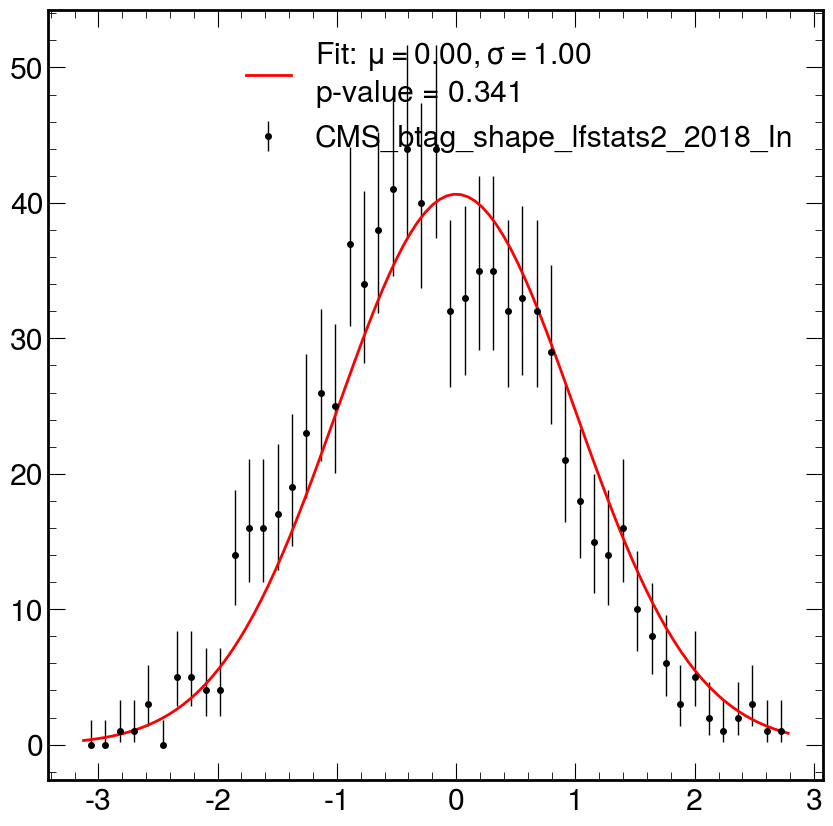

In [148]:
draw_plot('CMS_btag_shape_lfstats2_2018_In',mu=0,sigma=1)

In [149]:
f_toy = uproot.open('/data6/Users/yeonjoon/combine/CMSSW_14_1_0_pre4/src/CombineFactory/RunIIVcb/BTag_DL_LLVeto_SL_LLVeto_5f_rename/SigInjec/toys_Injec1p0/higgsCombine.Injec1p0.GenerateOnly.mH120.46.root')

In [150]:
nuis_df = pd.read_csv('/data6/Users/yeonjoon/combine/CMSSW_14_1_0_pre4/src/CombineFactory/RunIIVcb/BTag_DL_LLVeto_SL_LLVeto_5f_rename/SigInjec/fit_import_summary_mass120.csv')
nuis = nuis_df['Parameter']

In [151]:
nuis_df['WS_New_Val']

0      0.1197
1     -0.0244
2      0.2659
3     -0.5460
4      0.1647
        ...  
284    0.0531
285    0.4078
286    0.3217
287   -0.5088
288   -0.0496
Name: WS_New_Val, Length: 289, dtype: float64

In [152]:
from matplotlib.backends.backend_pdf import PdfPages
import matplotlib.pyplot as plt

# 저장할 PDF 파일 이름 설정
pdf_filename = 'nuisance_plots.pdf'

# PdfPages를 열어서 모든 플롯을 하나의 파일에 담습니다.
with PdfPages(pdf_filename) as pdf:
    # 1부터 끝까지 순회 (파이썬 인덱스 0을 건너뛰고 1부터 시작하는 경우)
    # 만약 처음(0)부터 하려면 range(len(nuis_df))로 변경하세요.
    for i in range(1, len(nuis_df)):
        nuis = nuis_df['Parameter'].iloc[i]
        mu_val = nuis_df['WS_New_Val'].iloc[i]
        sigma_origianl = nuis_df['WS_Orig_Err'].iloc[i]
        
        print(f"[{i}/{len(nuis_df)-1}] Drawing: {nuis}")
        
        # 플롯 그리기
        fig, edges = draw_plot(nuis + "_In", mu=mu_val, sigma=sigma_origianl)
        
        # 제목 추가 (선택 사항)
        fig.axes[0].set_title(f"Parameter: {nuis}")
        
        # 현재 fig를 PDF의 새로운 페이지로 저장
        pdf.savefig(fig)
        
        # 중요: 메모리 관리를 위해 그린 후 반드시 닫아줍니다.
        plt.close(fig)

print(f"모든 플롯이 '{pdf_filename}'에 성공적으로 저장되었습니다!")

[1/288] Drawing: CMS_btag_shape_cferr1


[2/288] Drawing: CMS_btag_shape_cferr2
[3/288] Drawing: CMS_btag_shape_hfstats1_2016postVFP
[4/288] Drawing: CMS_btag_shape_hfstats1_2016preVFP
[5/288] Drawing: CMS_btag_shape_hfstats1_2017
[6/288] Drawing: CMS_btag_shape_hfstats1_2018
[7/288] Drawing: CMS_btag_shape_hfstats2_2016postVFP
[8/288] Drawing: CMS_btag_shape_hfstats2_2016preVFP
[9/288] Drawing: CMS_btag_shape_hfstats2_2017
[10/288] Drawing: CMS_btag_shape_hfstats2_2018
[11/288] Drawing: CMS_btag_shape_hf
[12/288] Drawing: CMS_btag_shape_lfstats1_2016postVFP
[13/288] Drawing: CMS_btag_shape_lfstats1_2016preVFP
[14/288] Drawing: CMS_btag_shape_lfstats1_2017
[15/288] Drawing: CMS_btag_shape_lfstats1_2018
[16/288] Drawing: CMS_btag_shape_lfstats2_2016postVFP
[17/288] Drawing: CMS_btag_shape_lfstats2_2016preVFP
[18/288] Drawing: CMS_btag_shape_lfstats2_2017
[19/288] Drawing: CMS_btag_shape_lfstats2_2018
[20/288] Drawing: CMS_btag_shape_lf
[21/288] Drawing: CMS_TOP26001_mc_tune_CP5
[22/288] Drawing: ps_CR1_ttbar
[23/288] Drawing: 

In [153]:
import ROOT
import glob
import os
from rich.console import Console
from rich.progress import Progress, TextColumn, BarColumn, TaskProgressColumn, TimeRemainingColumn
from rich.panel import Panel
from rich.table import Table

# 불필요한 ROOT 경고 메시지 숨기기
ROOT.gErrorIgnoreLevel = ROOT.kWarning

console = Console()

def find_min_signal_bin_per_channel(file_pattern, channel_keyword="Signal"):
    toy_files = glob.glob(file_pattern)
    if not toy_files:
        console.print(f"[bold red]오류:[/bold red] 다음 패턴과 일치하는 파일을 찾을 수 없습니다 - {file_pattern}")
        return {}

    # 채널별 최솟값 정보를 저장할 딕셔너리
    # 구조: { "Signal_2016_El": {"count": 1.5, "info": {...}}, ... }
    channel_min_data = {}

    console.print(f"[bold blue]분석 대상 파일 수:[/bold blue] {len(toy_files)}")

    with Progress(
        TextColumn("[progress.description]{task.description}"),
        BarColumn(),
        TaskProgressColumn(),
        TimeRemainingColumn(),
        console=console
    ) as progress:
        
        task = progress.add_task("[cyan]Toy 파일 탐색 및 채널별 분류 중...", total=len(toy_files))

        for filepath in toy_files:
            filename = os.path.basename(filepath)
            f = ROOT.TFile.Open(filepath)
            
            if not f or f.IsZombie():
                if f: f.Close()
                progress.advance(task)
                continue

            toys_dir = f.Get("toys")
            if not toys_dir:
                f.Close()
                progress.advance(task)
                continue

            toy_keys = toys_dir.GetListOfKeys()
            
            for key in toy_keys:
                toy_name = key.GetName()
                d = toys_dir.Get(toy_name)

                if not d or not d.InheritsFrom("RooAbsData"):
                    continue

                for i in range(d.numEntries()):
                    row = d.get(i)
                    
                    if not row.find("CMS_channel"):
                        continue
                        
                    channel = row.getCatLabel("CMS_channel")

                    if channel_keyword in channel:
                        count = d.weight() / 100
                        
                        # [조건 1] 카운트가 0인 빈은 무시 (0보다 큰 경우만 처리)
                        if count > 0:
                            # 처음 발견된 채널이면 초기화
                            if channel not in channel_min_data:
                                channel_min_data[channel] = {"count": float('inf'), "info": {}}
                            
                            # [조건 2] 해당 채널의 현재 최솟값보다 작으면 업데이트
                            if count < channel_min_data[channel]["count"]:
                                channel_min_data[channel]["count"] = count
                                
                                th1x_val = row.getRealValue("CMS_th1x") if row.find("CMS_th1x") else 0.0
                                
                                channel_min_data[channel]["info"] = {
                                    "File": filename,
                                    "Toy": toy_name,
                                    "Bin": f"{th1x_val:.2f}"
                                }
            
            f.Close()
            progress.advance(task) 

    return channel_min_data

# --- 실행 부분 ---
base_dir = "/data6/Users/yeonjoon/combine/CMSSW_14_1_0_pre4/src/CombineFactory/RunIIVcb/BTag_DL_LLVeto_SL_LLVeto_5f_rename/SigInjec/toys_Injec1p0"
file_pattern = f"{base_dir}/higgsCombine*.root"

console.rule("[bold green]스캔 시작[/bold green]")
# 함수 이름이 변경되었고, 반환값이 딕셔너리 하나로 바뀌었습니다.
channel_results = find_min_signal_bin_per_channel(file_pattern, channel_keyword="Signal")
console.rule("[bold green]스캔 완료[/bold green]")

# 결과 요약 출력 (채널별 정리)
if channel_results:
    # 한눈에 보기 좋게 테이블 열 구성
    table = Table(show_header=True, header_style="bold magenta", title="채널별 Signal Bin 최소 카운트 (0 제외)")
    table.add_column("Channel", style="cyan", justify="left")
    table.add_column("Min Count", style="yellow", justify="right")
    table.add_column("Bin (CMS_th1x)", justify="right")
    table.add_column("Toy Name", style="dim")
    table.add_column("File Name", style="dim")
    
    # 채널 이름 알파벳 순으로 정렬하여 출력
    for channel in sorted(channel_results.keys()):
        data = channel_results[channel]
        info = data["info"]
        
        table.add_row(
            channel,
            f"{data['count']:.4f}",  # 가독성을 위해 소수점 4자리까지만 표시
            info["Bin"],
            info["Toy"],
            info["File"]
        )
        
    console.print(table)
else:
    console.print(Panel("[red]조건에 맞는 빈을 찾지 못했거나, 모든 빈의 카운트가 0입니다.[/red]", title="결과", expand=False))

──────────────────────────────────────────────────── 스캔 시작 ────────────────────────────────────────────────────

분석 대상 파일 수: 200

Output()

──────────────────────────────────────────────────── 스캔 완료 ────────────────────────────────────────────────────

                                      채널별 Signal Bin 최소 카운트 (0 제외)                                       
┏━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Channel               ┃ Min Count ┃ Bin (CMS_th1x) ┃ Toy Name ┃ File Name                                       ┃
┡━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ Signal_2016postVFP_El │   53.3400 │           5.50 │ toy_6    │ higgsCombine.Injec1p0.GenerateOnly.mH120.73.ro… │
│ Signal_2016postVFP_Mu │   36.7900 │           5.50 │ toy_9    │ higgsCombine.Injec1p0.GenerateOnly.mH120.59.ro… │
│ Signal_2016preVFP_El  │   91.3800 │           4.50 │ toy_4    │ higgsCombine.Injec1p0.GenerateOnly.mH120.92.ro… │
│ Signal_2016preVFP_Mu  │  133.6100 │           4.50 │ toy_1    │ higgsCombine.Injec1p0.GenerateOnly.mH120.88.ro… │
│ Signal_2017_El        │  150.2600 │           4.50 │ toy_2    │ higgsCombine.Injec1p0.GenerateOnly.mH120.8.root │
│ Signal_2017_Mu        │   64.4800 │           5.50 │ toy_10   │ higgsCombine.Injec1p0.GenerateOnly.mH120.82.ro… │
│ Signal_2018_El        │   70.7000 │           5.50 │ toy_3    │ higgsCombine.Injec1p0.GenerateOnly.mH120.20.ro… │
│ Signal_2018_Mu        │   30.3800 │           6.50 │ toy_1    │ higgsCombine.Injec1p0.GenerateOnly.mH120.99.ro… │
└───────────────────────┴───────────┴────────────────┴──────────┴─────────────────────────────────────────────────┘

In [154]:
from matplotlib.backends.backend_pdf import PdfPages
import matplotlib.pyplot as plt

# 저장할 PDF 파일 이름 설정
pdf_filename = 'nuisance_fit_plots.pdf'

# PdfPages를 열어서 모든 플롯을 하나의 파일에 담습니다.
with PdfPages(pdf_filename) as pdf:
    # 1부터 끝까지 순회 (파이썬 인덱스 0을 건너뛰고 1부터 시작하는 경우)
    # 만약 처음(0)부터 하려면 range(len(nuis_df))로 변경하세요.
    for i in range(1, len(nuis_df)):
        nuis = nuis_df['Parameter'].iloc[i]
        mu_val = nuis_df['WS_New_Val'].iloc[i]
        sigma_new = nuis_df['WS_New_Err'].iloc[i]
        
        print(f"[{i}/{len(nuis_df)-1}] Drawing: {nuis}")
        
        # 플롯 그리기
        fig, edges = draw_plot(nuis, mu=mu_val, sigma=sigma_new)
        
        # 제목 추가 (선택 사항)
        fig.axes[0].set_title(f"Parameter: {nuis}")
        
        # 현재 fig를 PDF의 새로운 페이지로 저장
        pdf.savefig(fig)
        
        # 중요: 메모리 관리를 위해 그린 후 반드시 닫아줍니다.
        plt.close(fig)

print(f"모든 플롯이 '{pdf_filename}'에 성공적으로 저장되었습니다!")

[1/288] Drawing: CMS_btag_shape_cferr1
[2/288] Drawing: CMS_btag_shape_cferr2
[3/288] Drawing: CMS_btag_shape_hfstats1_2016postVFP
[4/288] Drawing: CMS_btag_shape_hfstats1_2016preVFP
[5/288] Drawing: CMS_btag_shape_hfstats1_2017
[6/288] Drawing: CMS_btag_shape_hfstats1_2018
[7/288] Drawing: CMS_btag_shape_hfstats2_2016postVFP
[8/288] Drawing: CMS_btag_shape_hfstats2_2016preVFP
[9/288] Drawing: CMS_btag_shape_hfstats2_2017
[10/288] Drawing: CMS_btag_shape_hfstats2_2018
[11/288] Drawing: CMS_btag_shape_hf
[12/288] Drawing: CMS_btag_shape_lfstats1_2016postVFP
[13/288] Drawing: CMS_btag_shape_lfstats1_2016preVFP
[14/288] Drawing: CMS_btag_shape_lfstats1_2017
[15/288] Drawing: CMS_btag_shape_lfstats1_2018
[16/288] Drawing: CMS_btag_shape_lfstats2_2016postVFP
[17/288] Drawing: CMS_btag_shape_lfstats2_2016preVFP
[18/288] Drawing: CMS_btag_shape_lfstats2_2017
[19/288] Drawing: CMS_btag_shape_lfstats2_2018
[20/288] Drawing: CMS_btag_shape_lf
[21/288] Drawing: CMS_TOP26001_mc_tune_CP5
[22/288] D